# Modified Determinat

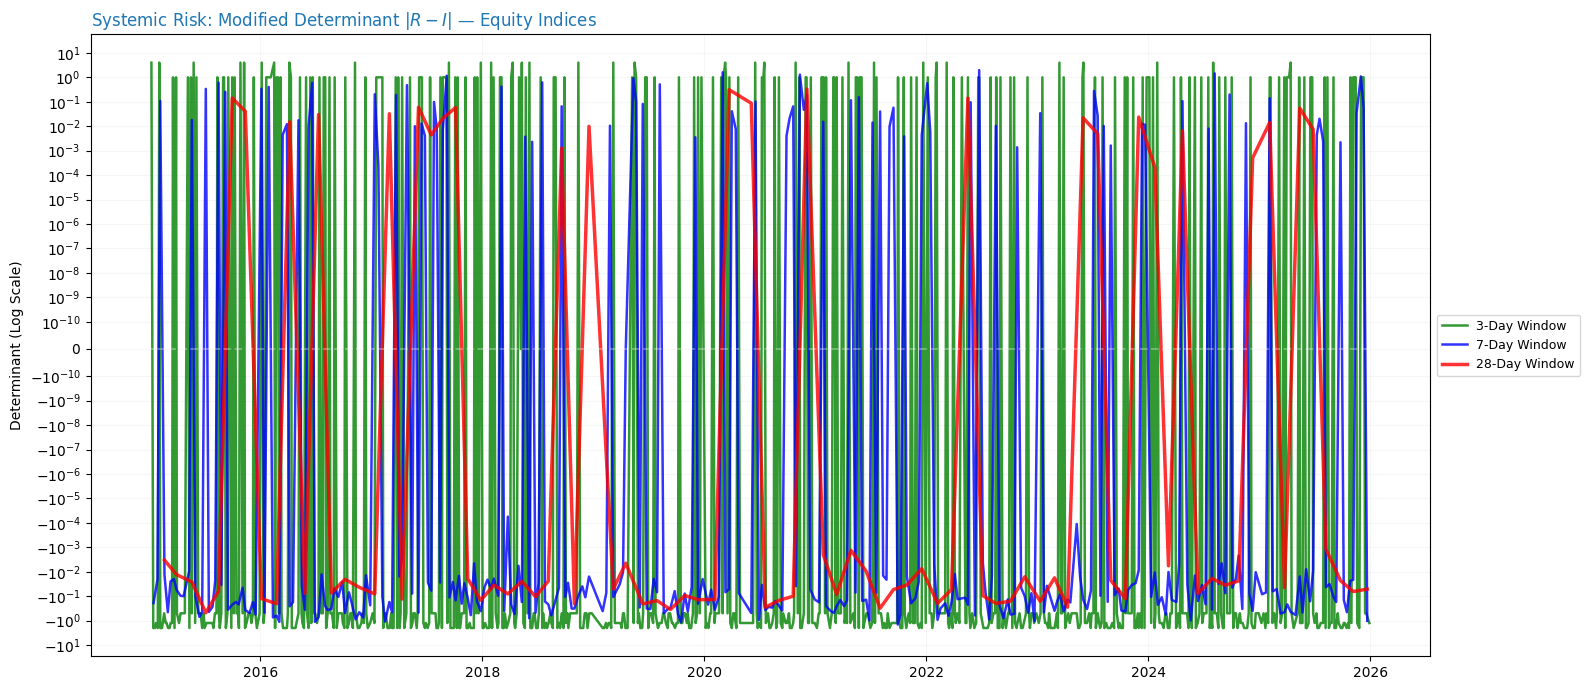

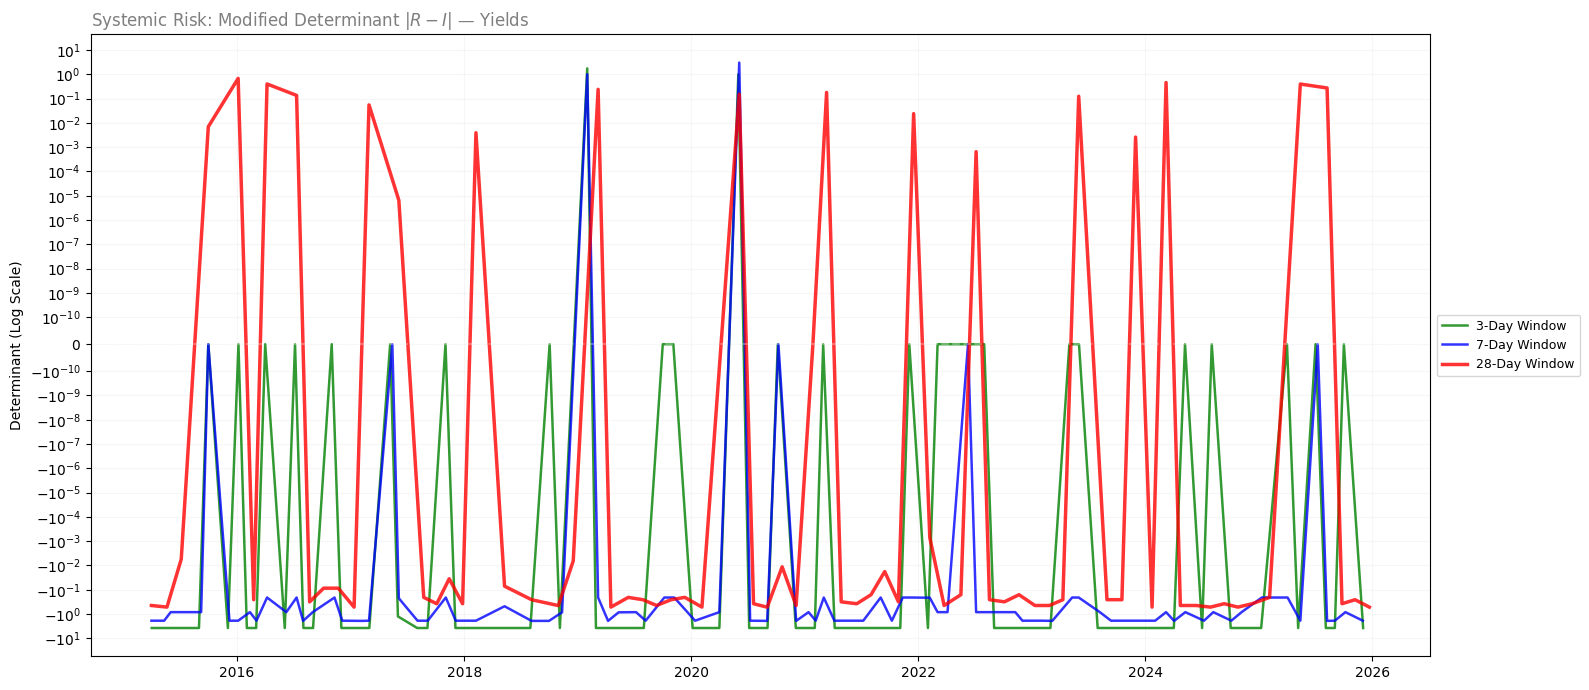

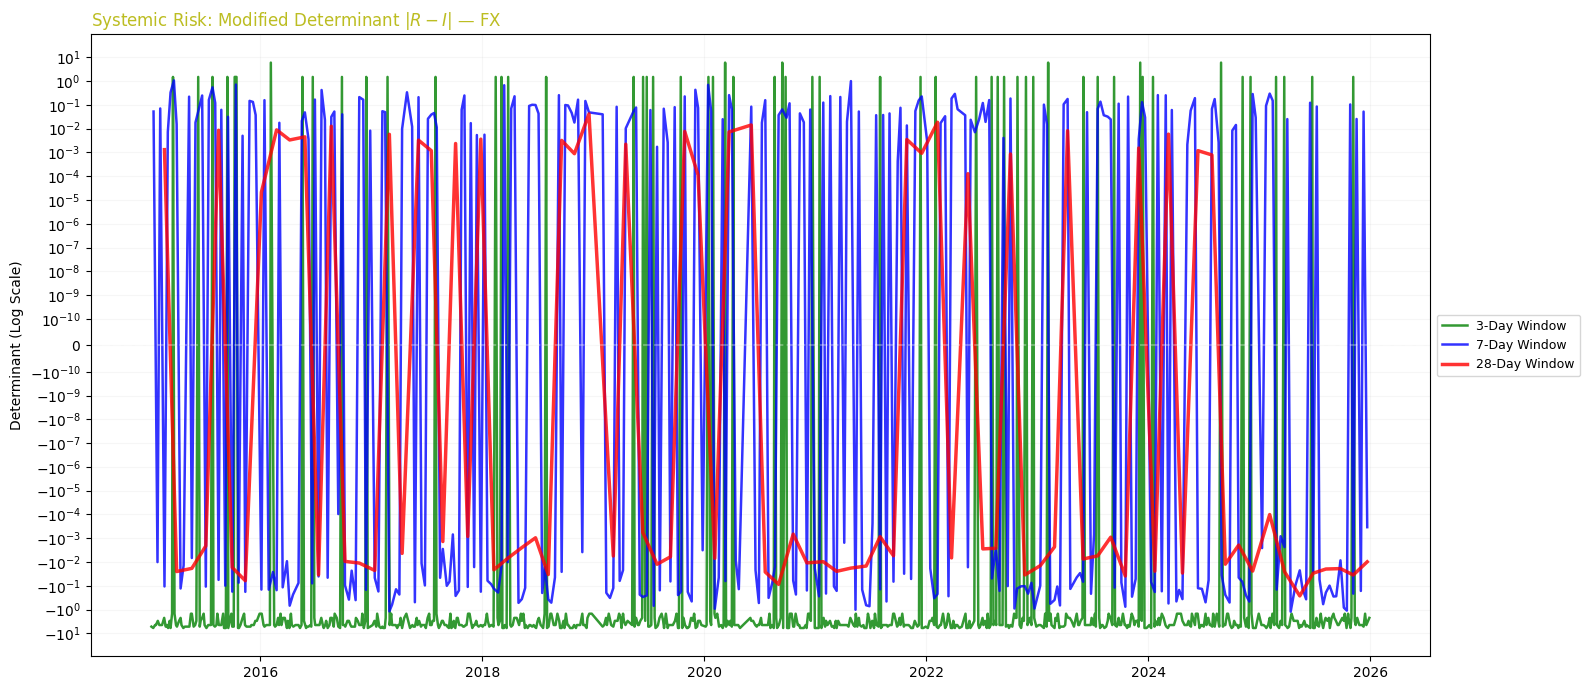

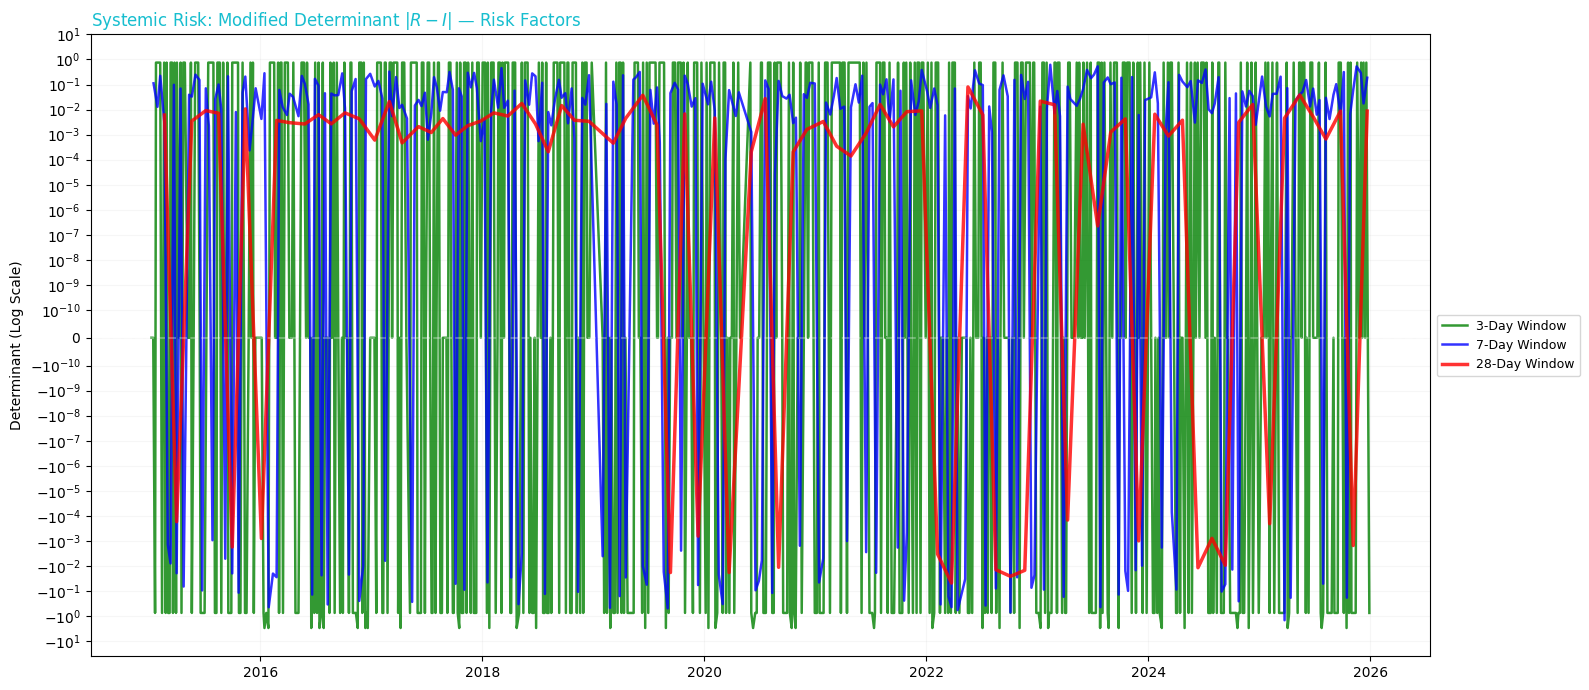

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import StringIO
import hashlib

# 1. Load data from GitHub
def load_data_from_github():
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]
    all_data = {}
    for file in files:
        url = base_url + file
        try:
            response = requests.get(url)
            response.raise_for_status()
            data = pd.read_csv(StringIO(response.text), index_col=0, parse_dates=True)
            data.columns = data.columns.str.replace('[^a-zA-Z0-9]', '_', regex=True)
            all_data[file.replace("streamlined_", "").replace(".csv", "").upper()] = data
        except Exception as e:
            print(f"Error loading {file}: {str(e)}")
            continue
    if not all_data:
        raise ValueError("No data files could be loaded.")
    return all_data

# 2. Configuration
DET_WINDOWS = [3, 7, 28]
WINDOW_COLORS = {
    3: 'green',
    7: 'blue',
    28: 'red'
}

# Index colors for consistent visualization
INDEX_COLORS = {
    'SP500': '#1f77b4',  # Blue
    'BOVESPA': '#ff7f0e',  # Orange
    'EUROSTOXX50': '#2ca02c',  # Green
    'FTSE100': '#d62728',  # Red
    'JSE40': '#9467bd',  # Purple
    'NIKKEI225': '#8c564b',  # Brown
    'ASX50': '#e377c2',  # Pink
    'Yields': '#7f7f7f',  # Gray
    'FX': '#bcbd22',  # Olive
    'Risk Factors': '#17becf'  # Cyan
}

# 3. Core Functions
def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

# 4. Main Analysis
def run_systemic_risk_analysis():
    # Load data
    all_data = load_data_from_github()
    all_assets = pd.concat(all_data.values(), axis=1)
    all_assets = all_assets.loc[:, ~all_assets.columns.duplicated()]

    # Calculate returns
    simple_returns = all_assets.pct_change().dropna()

    # Group assets
    asset_groups = {
        'Equity Indices': ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
        'Yields': [c for c in all_assets.columns if '10Y' in c],
        'FX': [c for c in all_assets.columns if any(x in c for x in ['USD', 'EUR', 'GBP'])],
        'Risk Factors': ['Gold', 'Oil', 'VIX', 'Bitcoin']
    }

    # Analyze each group
    for group_name, cols in asset_groups.items():
        valid_cols = [c for c in cols if c in simple_returns.columns]
        if len(valid_cols) < 2: continue

        plt.figure(figsize=(16, 7))
        group_returns = simple_returns[valid_cols]

        # Get group color
        color_key = 'SP500' if group_name == 'Equity Indices' else group_name
        group_color = INDEX_COLORS.get(color_key, '#ffffff')

        # Calculate and plot determinants
        for window in DET_WINDOWS:
            det_history = []
            for start in range(0, len(group_returns) - window, window):
                window_slice = group_returns.iloc[start:start+window]
                if window_slice.isnull().values.any():
                    continue
                corr_mat = window_slice.corr(method='spearman')
                det_val = calculate_modified_determinant(corr_mat)
                if not np.isnan(det_val):
                    det_history.append({'Date': window_slice.index[-1], 'Det': det_val})

            if det_history:
                df_det = pd.DataFrame(det_history).set_index('Date')
                plt.plot(df_det.index, df_det['Det'],
                        label=f'{window}-Day Window',
                        color=WINDOW_COLORS[window],
                        alpha=0.8,
                        linewidth=2.5 if window == 28 else 1.8)

        # Format plot
        plt.yscale('symlog', linthresh=1e-10)
        plt.axhline(0, color='white', linestyle='--', alpha=0.3)
        plt.title(f'Systemic Risk: Modified Determinant $|R - I|$ — {group_name}', loc='left', color=group_color)
        plt.ylabel('Determinant (Log Scale)')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
        plt.grid(True, alpha=0.1)
        plt.tight_layout()
        plt.show()

# Run the analysis
run_systemic_risk_analysis()


# Sign Detection

In [ ]:
# @title
# ---- Redefine variables from the first run ----
all_data = load_data_from_github()
all_assets = pd.concat(all_data.values(), axis=1)
all_assets = all_assets.loc[:, ~all_assets.columns.duplicated()]

simple_returns = all_assets.pct_change().dropna()

asset_groups = {
    'Equity Indices': ['SP500', 'BOVESPA', 'EUROSTOXX50', 'FTSE100', 'JSE40', 'NIKKEI225', 'ASX50'],
    'Yields': [c for c in all_assets.columns if '10Y' in c],
    'FX': [c for c in all_assets.columns if any(x in c for x in ['USD', 'EUR', 'GBP'])],
    'Risk Factors': ['Gold', 'Oil', 'VIX', 'Bitcoin']
}

print("✅ Variables ready — now run the sign analysis cell")


✅ Variables ready — now run the sign analysis cell


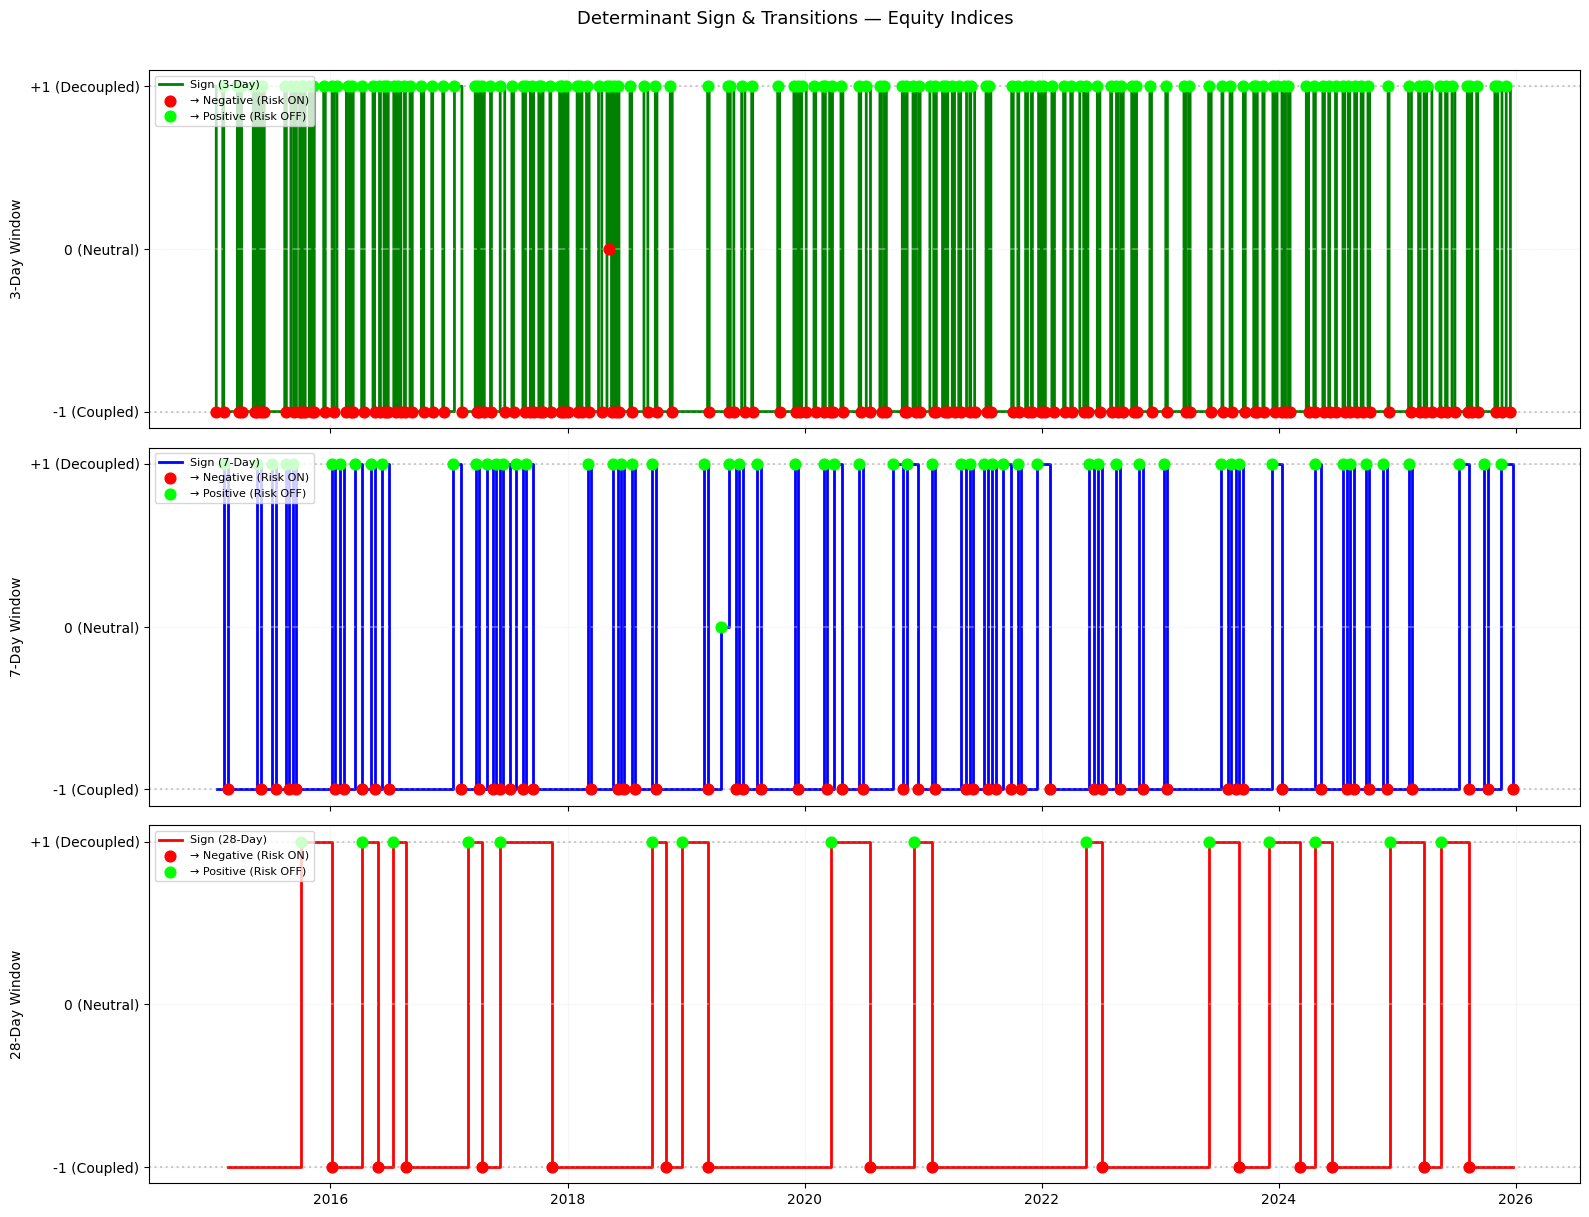

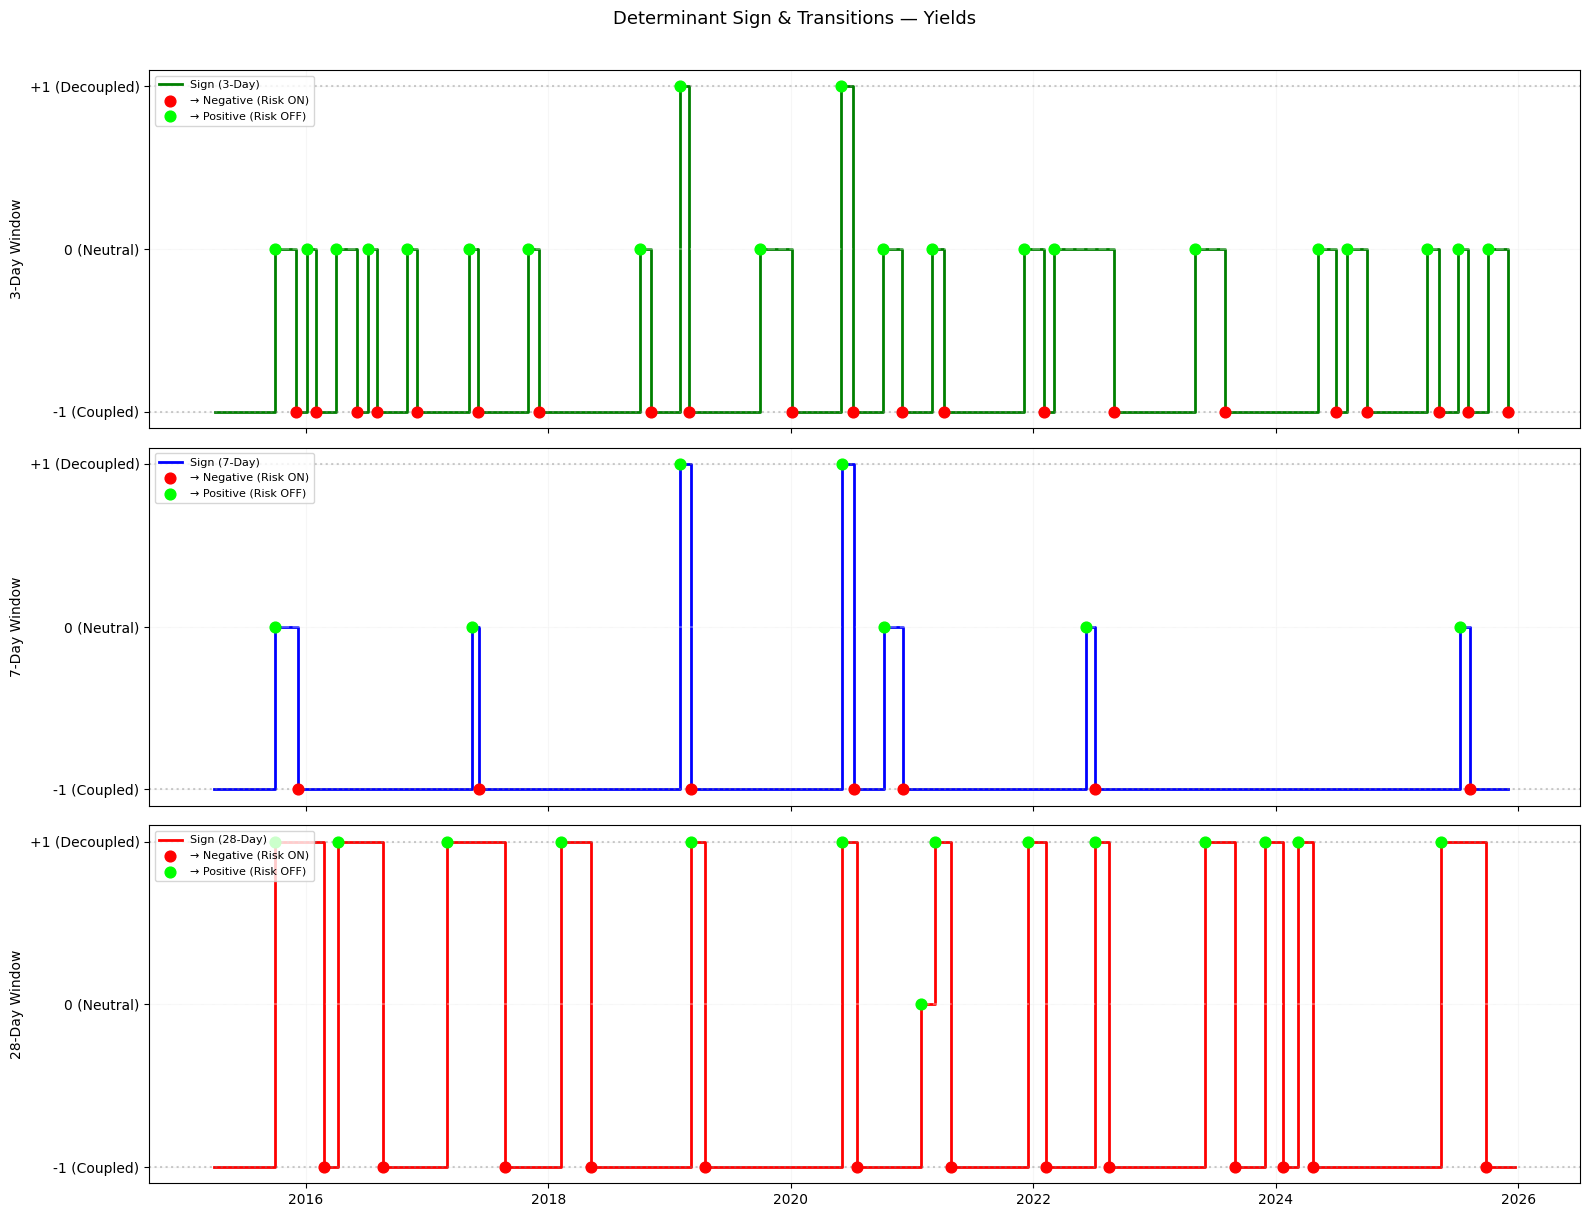

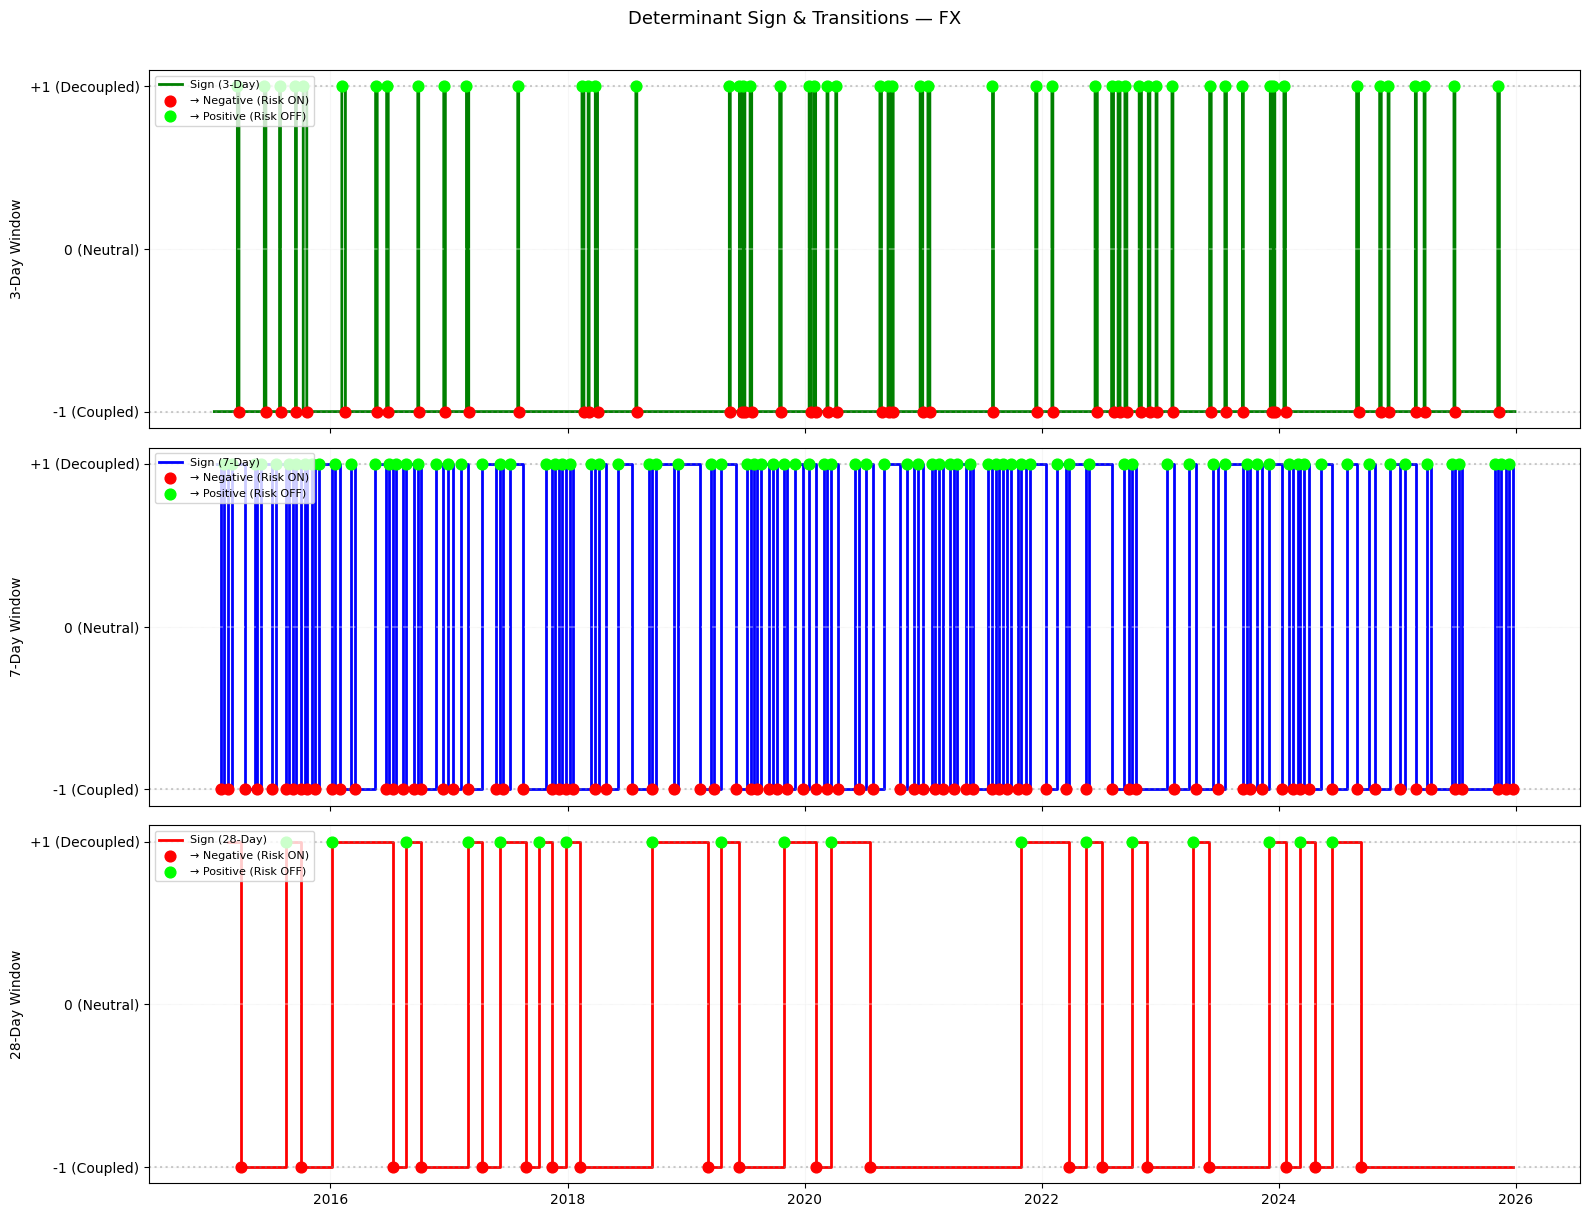

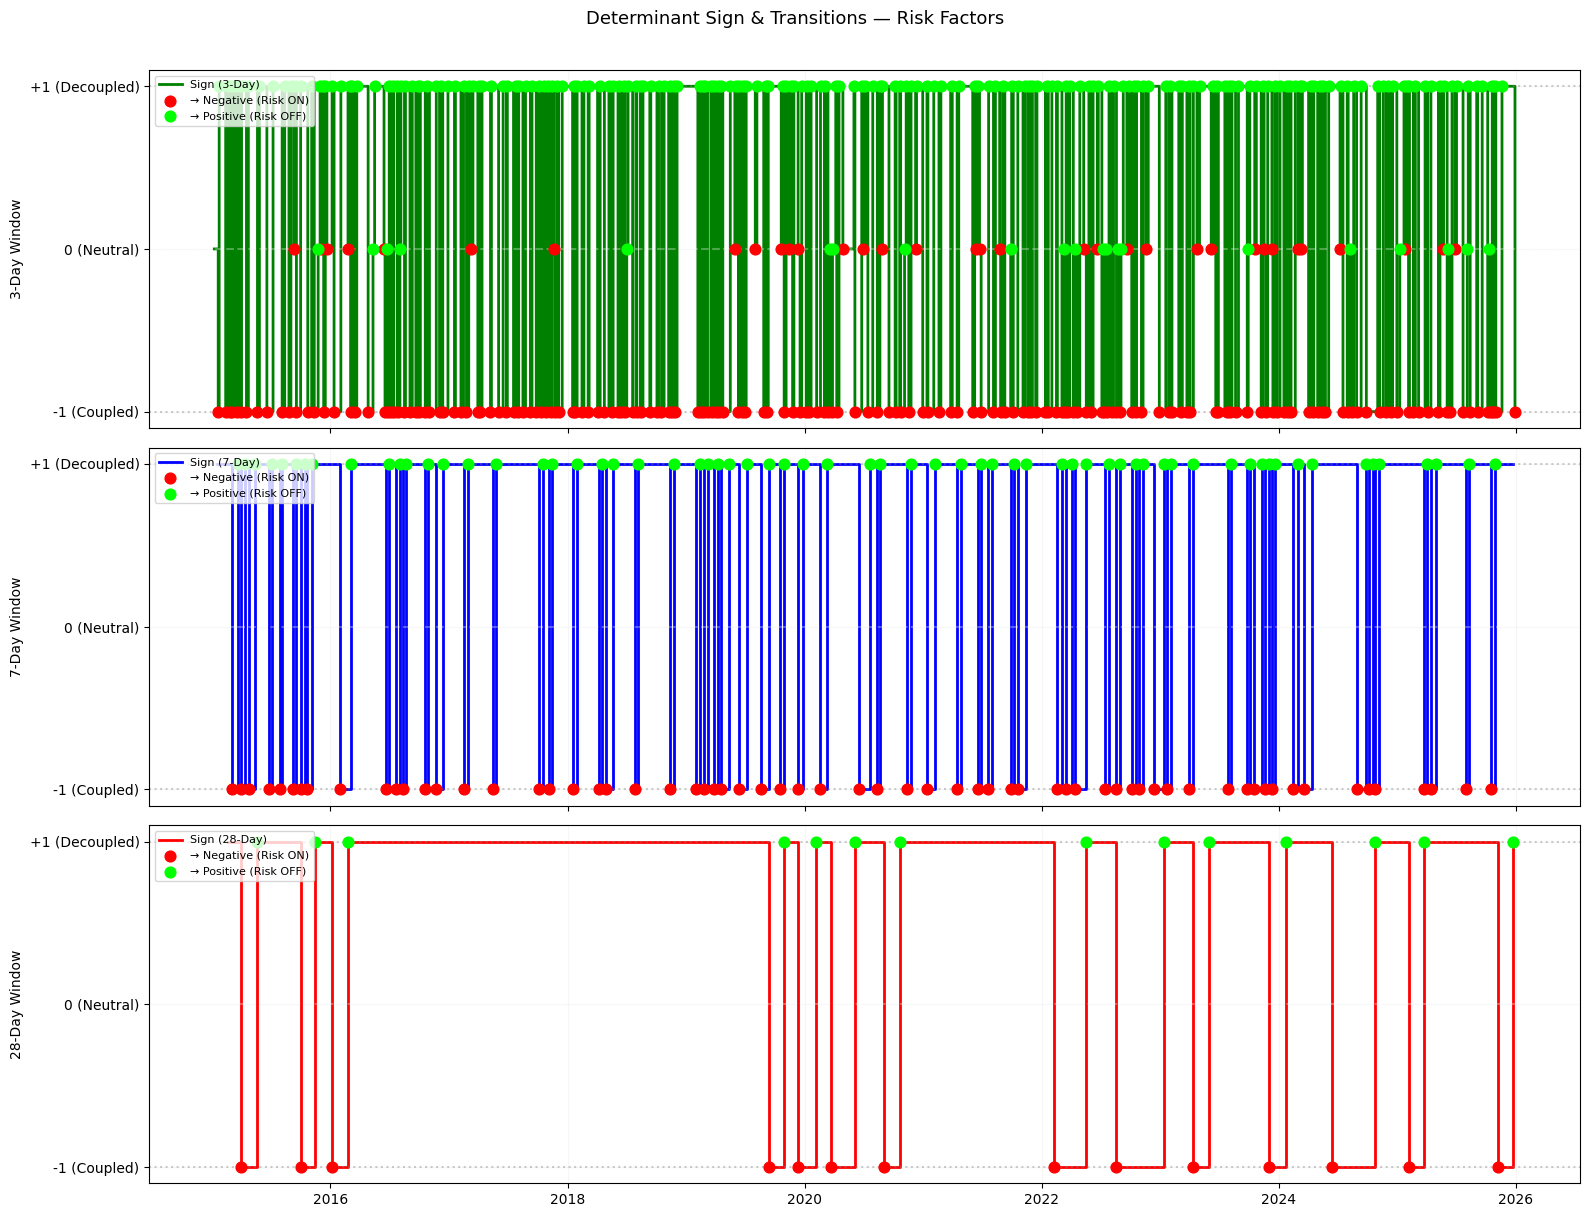


===== SIGN TRANSITION SIGNALS =====

Equity Indices
----------------------------------------

  3-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2025-10-31  -1.0   🔴 RISK ON (→ Negative)
2025-11-06   1.0  🟢 RISK OFF (→ Positive)
2025-11-19  -1.0   🔴 RISK ON (→ Negative)
2025-12-02   1.0  🟢 RISK OFF (→ Positive)
2025-12-15  -1.0   🔴 RISK ON (→ Negative)

  7-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2025-08-08  -1.0   🔴 RISK ON (→ Negative)
2025-09-25   1.0  🟢 RISK OFF (→ Positive)
2025-10-06  -1.0   🔴 RISK ON (→ Negative)
2025-11-17   1.0  🟢 RISK OFF (→ Positive)
2025-12-22  -1.0   🔴 RISK ON (→ Negative)

  28-Day Window — Last 5 Transitions:
            Sign                   Signal
Date                                     
2024-06-13  -1.0   🔴 RISK ON (→ Negative)
2024-12-10   1.0  🟢 RISK OFF (→ Positive)
2025-03-25  -1.0   🔴 RISK ON (→ Neg

In [ ]:
# @title
# ---- Sign Analysis of Modified Determinants ----
# Run this AFTER the main analysis block

# Re-collect determinant histories by group and window
sign_data = {}

for group_name, cols in asset_groups.items():
    valid_cols = [c for c in cols if c in simple_returns.columns]
    if len(valid_cols) < 2:
        continue

    group_returns = simple_returns[valid_cols]
    sign_data[group_name] = {}

    for window in DET_WINDOWS:
        det_history = []
        for start in range(0, len(group_returns) - window, window):
            window_slice = group_returns.iloc[start:start+window]
            if window_slice.isnull().values.any():
                continue
            corr_mat = window_slice.corr(method='spearman')
            det_val = calculate_modified_determinant(corr_mat)
            if not np.isnan(det_val):
                det_history.append({'Date': window_slice.index[-1], 'Det': det_val})

        if det_history:
            df_det = pd.DataFrame(det_history).set_index('Date')
            df_det['Sign'] = np.sign(df_det['Det'])  # -1, 0, or +1
            df_det['Sign_Change'] = df_det['Sign'].diff().fillna(0)  # transitions
            sign_data[group_name][window] = df_det

# ---- Plot Sign Changes ----
for group_name, windows in sign_data.items():
    fig, axes = plt.subplots(len(windows), 1, figsize=(16, 4 * len(windows)), sharex=True)
    if len(windows) == 1:
        axes = [axes]

    fig.suptitle(f'Determinant Sign & Transitions — {group_name}', fontsize=13, y=1.01)

    for ax, (window, df_det) in zip(axes, windows.items()):

        # Plot sign as step line
        ax.step(df_det.index, df_det['Sign'],
                where='post',
                color=WINDOW_COLORS[window],
                linewidth=2,
                label=f'Sign ({window}-Day)')

        # Highlight transitions
        transitions = df_det[df_det['Sign_Change'] != 0]

        pos_to_neg = transitions[transitions['Sign_Change'] < 0]
        neg_to_pos = transitions[transitions['Sign_Change'] > 0]

        ax.scatter(pos_to_neg.index, pos_to_neg['Sign'],
                   color='red', zorder=5, s=60, label='→ Negative (Risk ON)')
        ax.scatter(neg_to_pos.index, neg_to_pos['Sign'],
                   color='lime', zorder=5, s=60, label='→ Positive (Risk OFF)')

        # Reference lines
        ax.axhline(1,  color='gray', linestyle=':', alpha=0.4)
        ax.axhline(0,  color='white', linestyle='--', alpha=0.3)
        ax.axhline(-1, color='gray', linestyle=':', alpha=0.4)

        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels(['-1 (Coupled)', '0 (Neutral)', '+1 (Decoupled)'])
        ax.set_ylabel(f'{window}-Day Window')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.1)

    plt.tight_layout()
    plt.show()

# ---- Print Signal Summary ----
print("\n===== SIGN TRANSITION SIGNALS =====")
for group_name, windows in sign_data.items():
    print(f"\n{group_name}")
    print("-" * 40)
    for window, df_det in windows.items():
        transitions = df_det[df_det['Sign_Change'] != 0][['Sign', 'Sign_Change']]
        transitions['Signal'] = transitions['Sign_Change'].apply(
            lambda x: '🔴 RISK ON (→ Negative)' if x < 0 else '🟢 RISK OFF (→ Positive)'
        )
        print(f"\n  {window}-Day Window — Last 5 Transitions:")
        print(transitions[['Sign', 'Signal']].tail(5).to_string())


# Signal Generation Function

In [ ]:
# @title
def get_regime_signal(corr_matrix, threshold=0.0):
    """
    Returns:
        - 1.0 : Risk OFF (Positive determinant) → Invest fully
        - 0.5 : Neutral (Near zero) → Maintain allocation
        - 0.0 : Risk ON (Negative determinant) → Reduce exposure
    """
    det = calculate_modified_determinant(corr_matrix)
    if np.isnan(det):
        return 0.5  # Neutral if calculation fails

    if det > threshold:
        return 1.0  # Risk OFF
    elif det < -threshold:
        return 0.0  # Risk ON
    else:
        return 0.5  # Neutral zone


# Regime-Adjusted EW Portfolio

In [ ]:
# @title
def regime_adjusted_ew_portfolio(price_df,
                                signal_window=28,
                                threshold=0.0,
                                rebalance_freq="ME"):
    """
    Equally-weighted portfolio with dynamic exposure based on systemic risk regime.

    Args:
        price_df: DataFrame of asset prices
        signal_window: Lookback window (days) for correlation calculation
        threshold: Determinant threshold to classify Risk ON/OFF
        rebalance_freq: Rebalancing frequency ('ME'=monthly end)

    Returns:
        pd.Series: Daily log returns of the regime-adjusted portfolio
    """
    lr = get_log_returns(price_df)  # Daily log returns
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample(rebalance_freq).last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets  # Start equally weighted

    # Initial NAV tracking
    nav = 1.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    reb_idx = 0
    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
            else:
                exposure = 0.5  # Neutral if insufficient data

            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = exposure * (current_weights @ lr.loc[date].values)

        # Update NAV (for visualization)
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav


# Run All Strategies Together

🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...
Determinant: -0.0000
Date: 2015-03-02, Exposure: 0.50
Determinant: 0.0000
Date: 2015-03-31, Exposure: 0.50
Determinant: -0

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Determinant: nan
Date: 2018-04-03, Exposure: 0.50
Determinant: nan
Date: 2018-04-30, Exposure: 0.50
Determinant: -0.0039
Date: 2018-06-01, Exposure: 0.50
Determinant: nan
Date: 2018-07-02, Exposure: 0.50
Determinant: nan
Date: 2018-07-31, Exposure: 0.50
Determinant: -0.0002
Date: 2018-08-31, Exposure: 0.50
Determinant: -0.0010
Date: 2018-10-01, Exposure: 0.50
Determinant: 0.0035
Date: 2018-10-31, Exposure: 0.50
Determinant: -0.0011
Date: 2018-11-30, Exposure: 0.50
Determinant: nan
Date: 2019-01-04, Exposure: 0.50
Determinant: nan
Date: 2019-01-31, Exposure: 0.50
Determinant: nan
Date: 2019-02-28, Exposure: 0.50
Determinant: -0.0002
Date: 2019-04-01, Exposure: 0.50
Determinant: -0.0000
Date: 2019-05-07, Exposure: 0.50
Determinant: 0.0002
Date: 2019-05-31, Exposure: 0.50
Determinant: 0.0006
Date: 2019-07-01, Exposure: 0.50
Determinant: 0.0010
Date: 2019-07-31, Exposure: 0.50
Determinant: -0.0001
Date: 2019-09-03, Exposure: 0.50
Determinant: nan
Date: 2019-09-30, Exposure: 0.50
Determinan

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


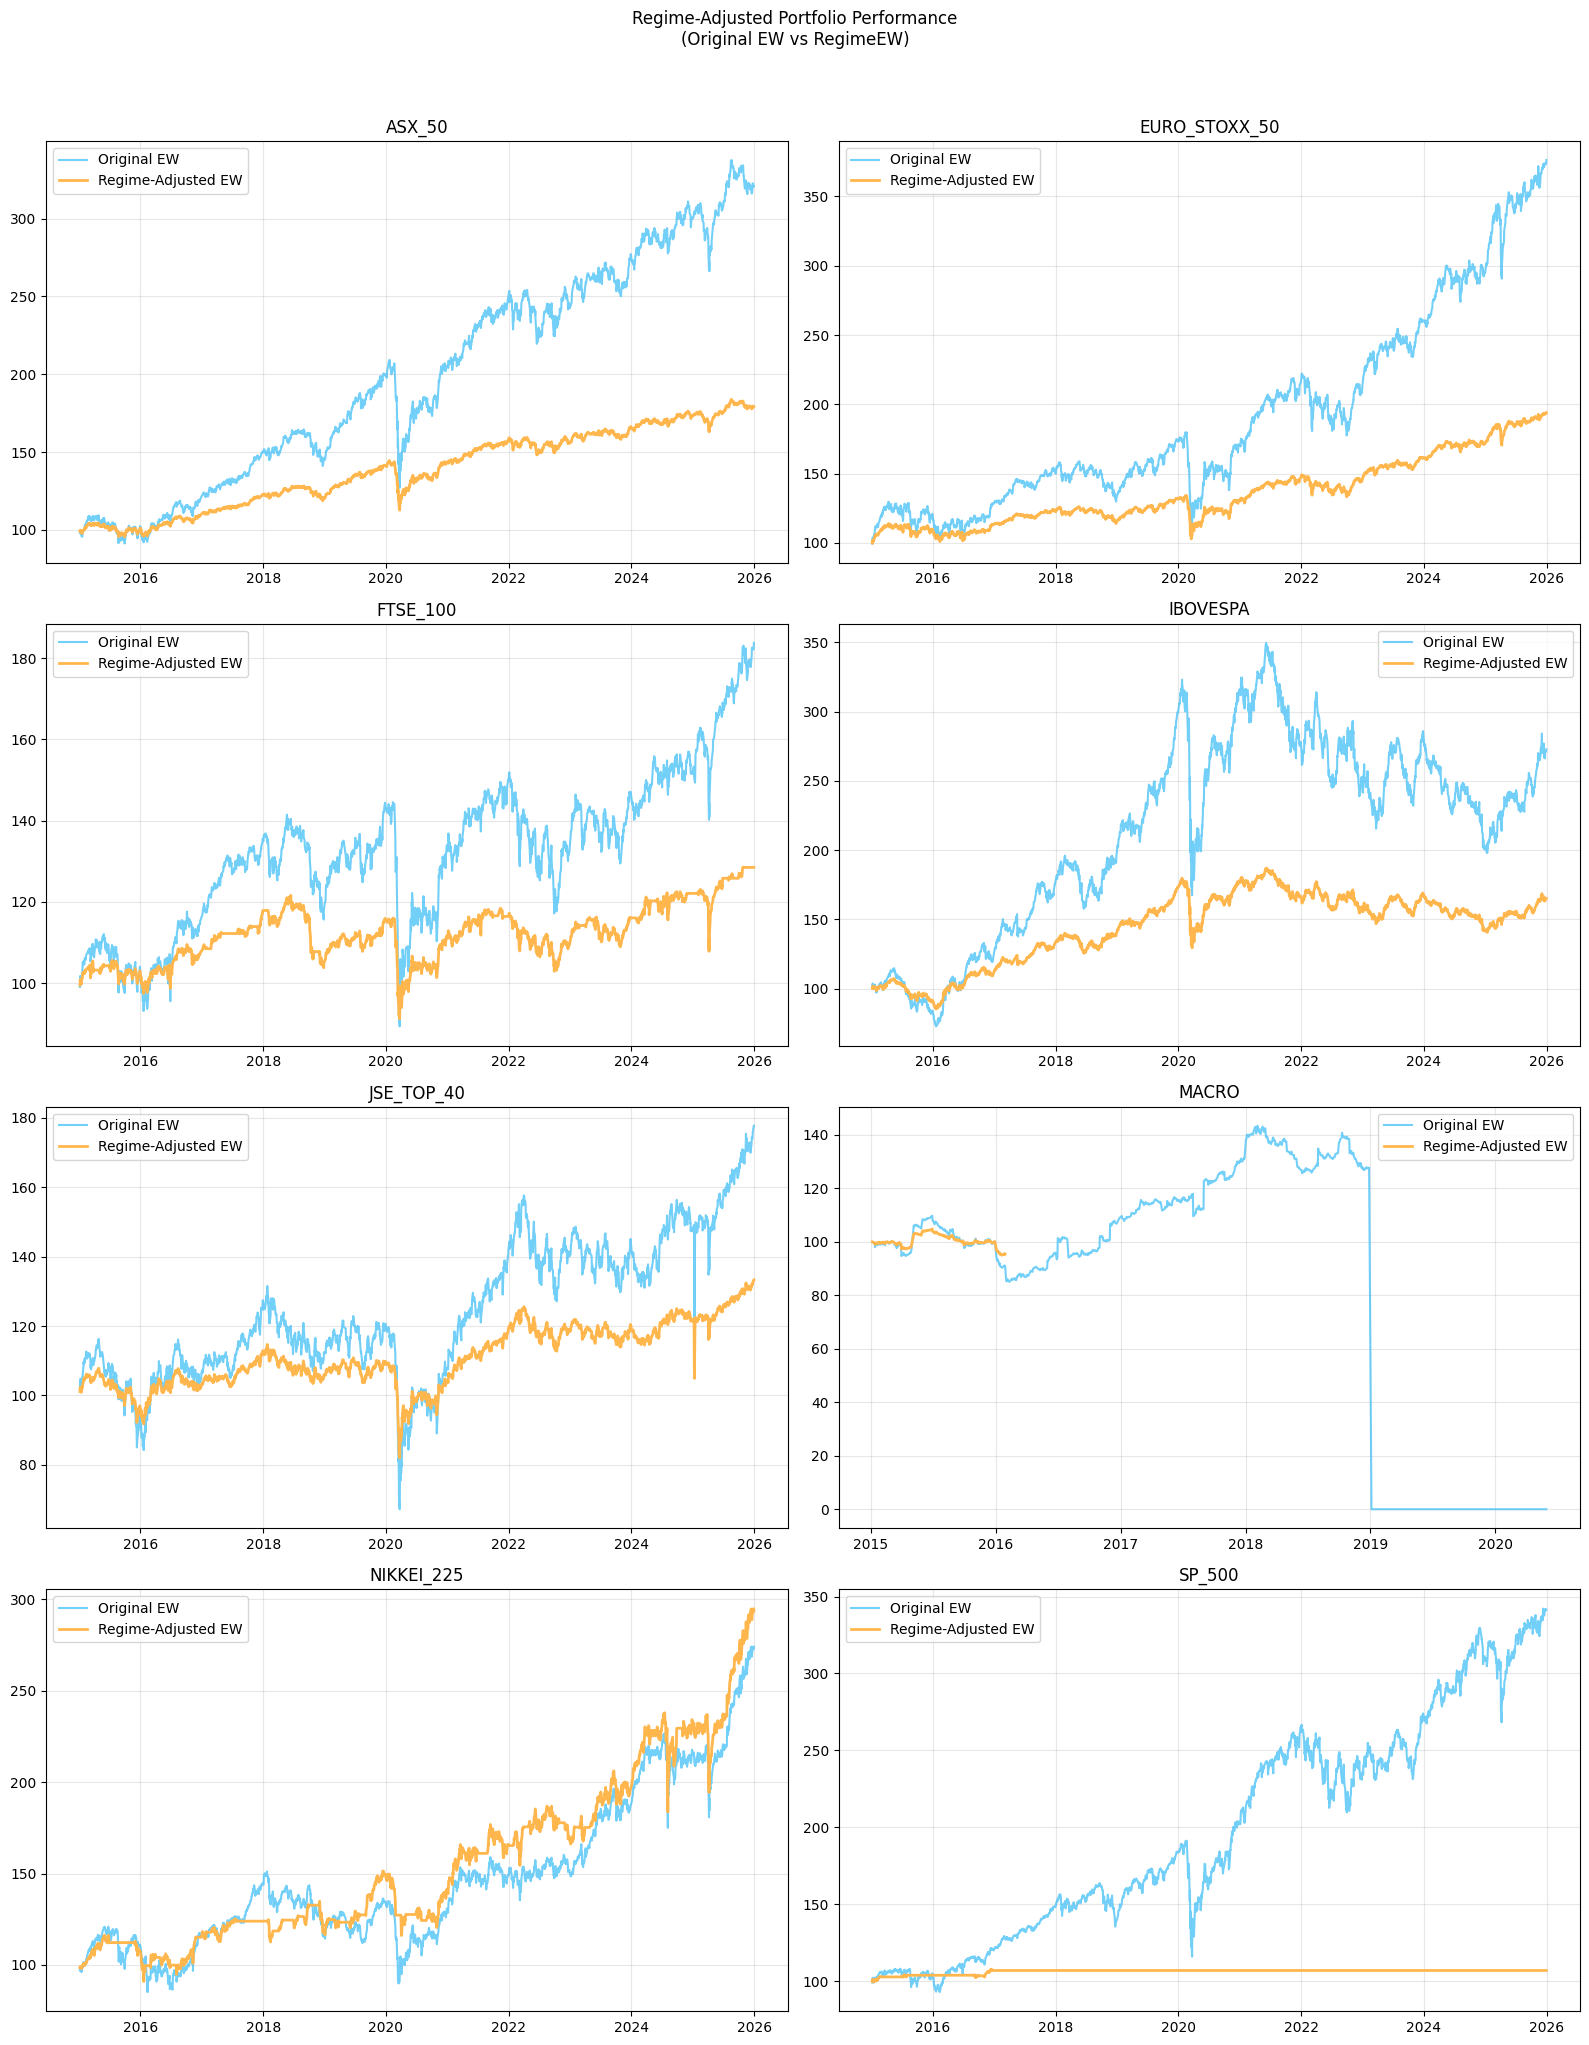


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0):
    """
    Returns exposure level based on regime:
    - 1.0: Risk OFF (Positive determinant) → Invest fully
    - 0.5: Neutral → Maintain allocation
    - 0.0: Risk ON (Negative determinant) → Reduce exposure
    """
    det = calculate_modified_determinant(corr_matrix)
    print(f"Determinant: {det:.4f}")  # DEBUG

    if np.isnan(det):
        return 0.5  # Neutral if calculation fails

    # More aggressive regime detection
    if det > 0.1:
        return 1.0  # Risk OFF - invest fully
    elif det < -0.1:
        return 0.0  # Risk ON - reduce exposure
    else:
        return 0.5  # Neutral zone

# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

def regime_adjusted_ew_portfolio(price_df, signal_window=28, threshold=0.0):
    """
    Equally-weighted portfolio with dynamic exposure based on systemic risk regime.
    FIXED VERSION - now properly applies regime signals
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    # Track NAV - START AT 100 (not 1.0) for better visualization
    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    exposure = 0.5  # Start neutral
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
                print(f"Date: {date.date()}, Exposure: {exposure:.2f}")  # DEBUG
            else:
                exposure = 0.5  # Neutral if insufficient data
            reb_idx += 1

        # Apply exposure to returns - FIXED: Use proper returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav


# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")


# Signal Trading Strategy with Proper Data Handling

🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...
Date: 2015-03-02, Exposure: 0.40
Date: 2015-03-31, Exposure: 0.40
Date: 2015-04-30, Exposure: 0.10
Date: 2015-06-01, Expos

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.10
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.10
Date: 2017-03-31, Exposure: 0.10
Date: 2017-05-02, Exposure: 0.10
Date: 2017-05-31, Exposure: 0.10
Date: 2017-06-30, Exposure: 0.10
Date: 2017-07-31, Exposure: 0.10
Date: 2017-08-31, Exposure: 0.10
Date: 2017-10-02, Exposure: 0.10
Date: 2017-10-31, Exposure: 0.10
Date: 2017-11-30, Exposure: 0.10
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.10
Date: 2018-02-28, Exposure: 0.10
Date: 2018-04-03, Exposure: 0.40
Date: 2018-04-30, Exposure: 0.40
Date: 2018-06-01, Exposure: 0.10
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.10
Date: 2018-08-31, Exposure: 0.10
Date: 2018-10-01, Exposure: 0.10
Date: 2018-10-31, Exposure: 0.10
Date: 2018-11-30, Exposure: 0.10
Date: 2019

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-03-31, Exposure: 0.40
Date: 2016-05-06, Exposure: 0.40
Date: 2016-05-31, Exposure: 0.10
Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.40
Date: 2016-08-31, Exposure: 0.40
Date: 2016-09-30, Exposure: 0.40
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.40
Date: 2017-03-31, Exposure: 0.40
Date: 2017-05-02, Exposure: 0.40
Date: 2017-05-31, Exposure: 0.40
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.10
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.10
Date: 2017-11-30, Exposure: 0.40
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.40
Date: 2018-02-28, Exposure: 0.40
Date: 2018-04-03, Exposure: 0.10
Date: 2018-04-30, Exposure: 0.10
Date: 2018-06-01, Exposure: 0.40
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.10
Date: 2018-08-31, Exposure: 0.40
Date: 2018

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.10
Date: 2017-03-01, Exposure: 0.10
Date: 2017-03-31, Exposure: 0.10
Date: 2017-05-02, Exposure: 0.10
Date: 2017-05-31, Exposure: 0.10
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.40
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.40
Date: 2017-11-30, Exposure: 0.40
Date: 2018-01-02, Exposure: 0.40
Date: 2018-01-31, Exposure: 0.10
Date: 2018-02-28, Exposure: 0.10
Date: 2018-04-03, Exposure: 0.10
Date: 2018-04-30, Exposure: 0.10
Date: 2018-06-01, Exposure: 0.40
Date: 2018-07-02, Exposure: 0.10
Date: 2018-07-31, Exposure: 0.40
Date: 2018-08-31, Exposure: 0.40
Date: 2018-10-01, Exposure: 0.40
Date: 2018-10-31, Exposure: 0.10
Date: 2018-11-30, Exposure: 0.10
Date: 2019

/usr/local/lib/python3.12/dist-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Date: 2015-06-30, Exposure: 0.10
Date: 2015-07-31, Exposure: 0.10
Date: 2015-09-01, Exposure: 0.10
Date: 2015-09-30, Exposure: 0.10
Date: 2015-11-04, Exposure: 0.10
Date: 2015-11-30, Exposure: 0.40
Date: 2016-01-04, Exposure: 0.10
Date: 2016-02-01, Exposure: 0.10
Date: 2016-02-29, Exposure: 0.10
Date: 2016-03-31, Exposure: 0.40
Date: 2016-05-06, Exposure: 0.40
Date: 2016-05-31, Exposure: 0.40
Date: 2016-06-30, Exposure: 0.10
Date: 2016-08-01, Exposure: 0.10
Date: 2016-08-31, Exposure: 0.10
Date: 2016-09-30, Exposure: 0.10
Date: 2016-10-31, Exposure: 0.10
Date: 2016-11-30, Exposure: 0.10
Date: 2017-01-04, Exposure: 0.40
Date: 2017-01-31, Exposure: 0.40
Date: 2017-03-01, Exposure: 0.40
Date: 2017-03-31, Exposure: 0.40
Date: 2017-05-02, Exposure: 0.40
Date: 2017-05-31, Exposure: 0.40
Date: 2017-06-30, Exposure: 0.40
Date: 2017-07-31, Exposure: 0.40
Date: 2017-08-31, Exposure: 0.40
Date: 2017-10-02, Exposure: 0.40
Date: 2017-10-31, Exposure: 0.40
Date: 2017-11-30, Exposure: 0.40
Date: 2018

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


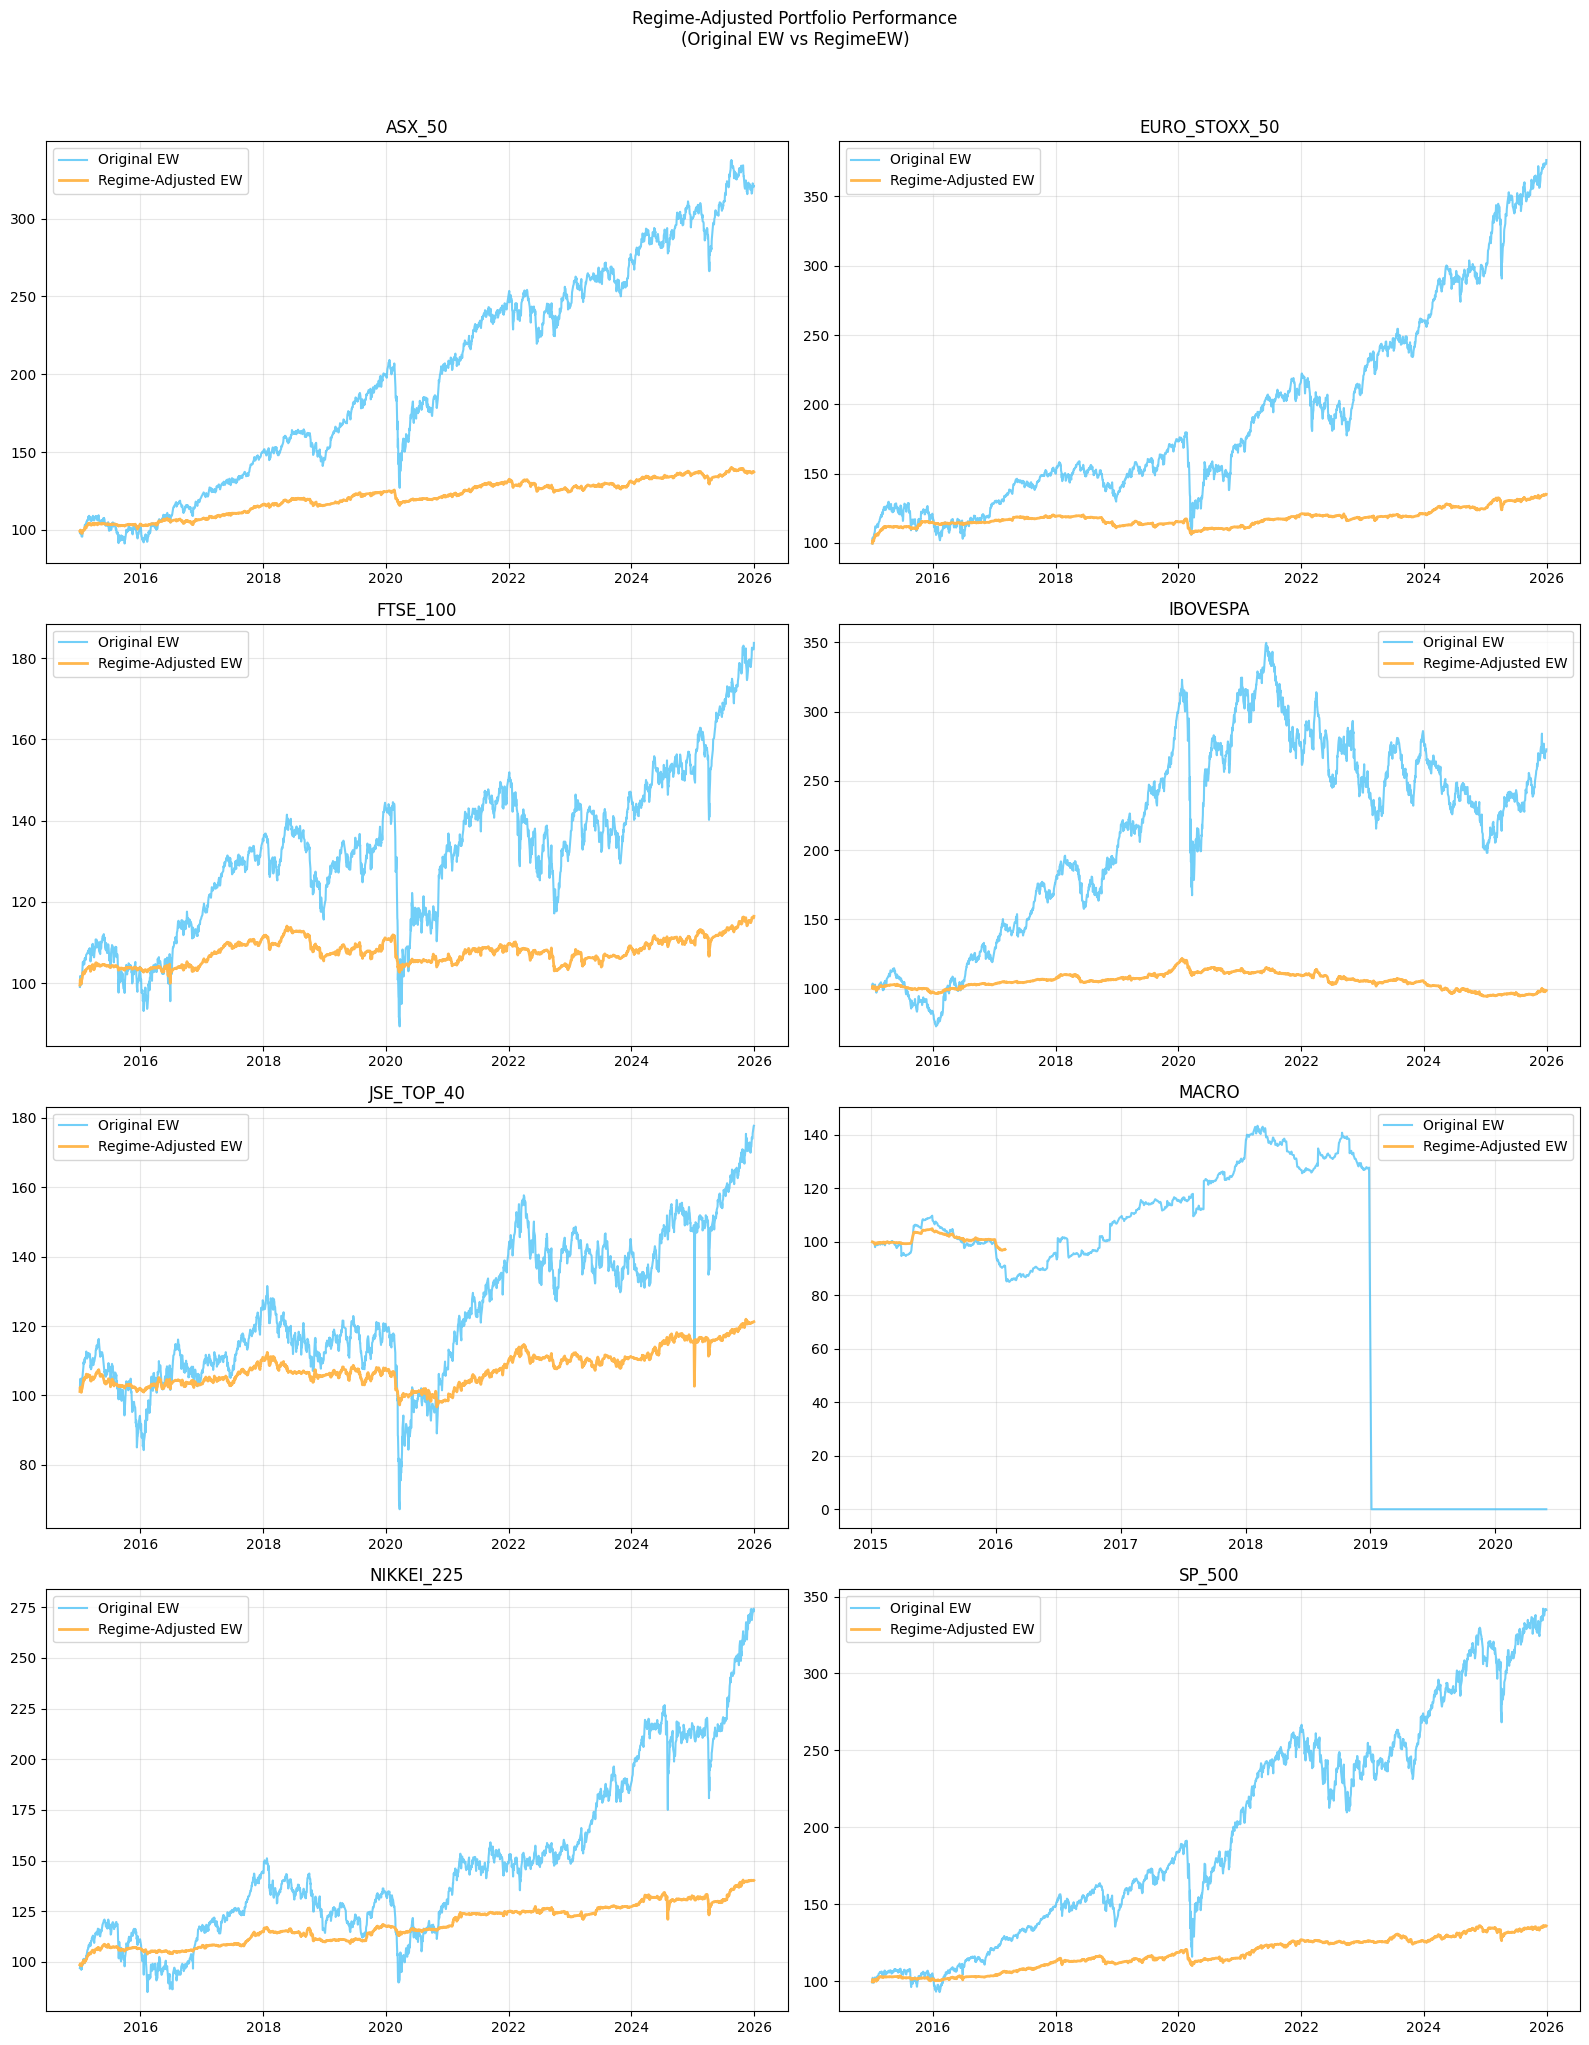


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. ENHANCED REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0):
    """
    ROBUST REGIME DETECTION that handles numerical issues
    - Uses regularized correlation matrix
    - Handles eigenvalue convergence problems
    - Provides fallback values when calculations fail
    """
    n_assets = corr_matrix.shape[0]

    # Regularize the correlation matrix to ensure positive definiteness
    try:
        # Add small regularization to diagonal
        regularized_corr = corr_matrix.copy()
        np.fill_diagonal(regularized_corr.values,
                        regularized_corr.values.diagonal() + 1e-8)

        # Calculate determinant with regularized matrix
        det = np.linalg.det(regularized_corr)

        # Calculate average pairwise correlation (excluding diagonal)
        mask = np.ones(regularized_corr.shape, dtype=bool)
        np.fill_diagonal(mask, 0)
        avg_corr = regularized_corr.values[mask].mean()

        # Calculate participation ratio with error handling
        try:
            eigenvalues = np.linalg.eigvalsh(regularized_corr)
            participation_ratio = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)
        except np.linalg.LinAlgError:
            # If eigenvalues don't converge, use average correlation as fallback
            participation_ratio = avg_corr

        # Composite regime indicator with safeguards
        regime_score = (
            0.4 * (det > 0.05) +
            0.3 * (avg_corr < 0.3) +
            0.3 * (participation_ratio < 1.5)
        )

        # Convert to exposure level with fallback
        if regime_score > 0.7:
            return 1.0   # Strong risk-off regime
        elif regime_score > 0.4:
            return 0.7   # Moderate risk-off
        elif regime_score > 0.2:
            return 0.4   # Moderate risk-on
        else:
            return 0.1   # Strong risk-on regime

    except Exception as e:
        print(f"   ⚠️  Regime detection failed for this period: {str(e)}")
        print(f"   → Using neutral exposure (0.5) as fallback")
        return 0.5  # Fallback to neutral exposure

# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

def regime_adjusted_ew_portfolio(price_df, signal_window=28, threshold=0.0):
    """
    FIXED VERSION - Equally-weighted portfolio with dynamic exposure based on systemic risk regime
    Properly initializes exposure variable before loop
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    # Track NAV - START AT 100 (not 1.0) for better visualization
    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    # FIXED: Initialize exposure BEFORE the loop
    exposure = 0.5  # Start neutral
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            # Calculate correlation matrix using signal_window
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 20:  # Minimum observations
                corr_mat = hist.corr(method='spearman')
                exposure = get_regime_signal(corr_mat, threshold)
                print(f"Date: {date.date()}, Exposure: {exposure:.2f}")  # DEBUG
            else:
                exposure = 0.5  # Neutral if insufficient data
            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav

# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")


🔍 Loading: streamlined_asx_50.csv
   ✅ Loaded ASX_50 with 44 assets
🔍 Loading: streamlined_euro_stoxx_50.csv
   ✅ Loaded EURO_STOXX_50 with 46 assets
🔍 Loading: streamlined_ftse_100.csv
   ✅ Loaded FTSE_100 with 90 assets
🔍 Loading: streamlined_ibovespa.csv
   ✅ Loaded IBOVESPA with 56 assets
🔍 Loading: streamlined_jse_top_40.csv
   ✅ Loaded JSE_TOP_40 with 31 assets
🔍 Loading: streamlined_macro.csv
   ✅ Loaded MACRO with 22 assets
🔍 Loading: streamlined_nikkei_225.csv
   ✅ Loaded NIKKEI_225 with 217 assets
🔍 Loading: streamlined_s&p_500.csv
   ✅ Loaded SP_500 with 460 assets

✅ Successfully loaded 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📊 Working with 8 indices:
['ASX_50', 'EURO_STOXX_50', 'FTSE_100', 'IBOVESPA', 'JSE_TOP_40', 'MACRO', 'NIKKEI_225', 'SP_500']

📈 Running strategies for ASX_50...

📈 Running strategies for EURO_STOXX_50...

📈 Running strategies for FTSE_100...

📈 Running strategies for IBOVESPA...

📈 

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)



📈 Running strategies for NIKKEI_225...

📈 Running strategies for SP_500...

PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW

📊 ASX_50:
  EW: Sharpe=0.61, DD=-39.27%
  RegimeEW: Sharpe=0.49, DD=-22.07%

📊 EURO_STOXX_50:
  EW: Sharpe=0.58, DD=-41.13%
  RegimeEW: Sharpe=0.48, DD=-23.27%

📊 FTSE_100:
  EW: Sharpe=0.25, DD=-38.17%
  RegimeEW: Sharpe=0.14, DD=-21.37%

📊 IBOVESPA:
  EW: Sharpe=0.33, DD=-48.18%
  RegimeEW: Sharpe=0.25, DD=-28.01%

📊 JSE_TOP_40:
  EW: Sharpe=0.17, DD=-48.93%
  RegimeEW: Sharpe=0.08, DD=-28.54%

📊 MACRO:
  EW: Sharpe=nan, DD=-100.0%
  RegimeEW: Sharpe=nan, DD=-100.0%

📊 NIKKEI_225:
  EW: Sharpe=0.4, DD=-40.5%
  RegimeEW: Sharpe=0.31, DD=-22.86%

📊 SP_500:
  EW: Sharpe=0.56, DD=-39.43%
  RegimeEW: Sharpe=0.46, DD=-22.17%

FULL PERFORMANCE SUMMARY:
               Portfolio  Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Total Return (%)
             ASX_50 — EW            12.18                16.82          0.61            -39.27 

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


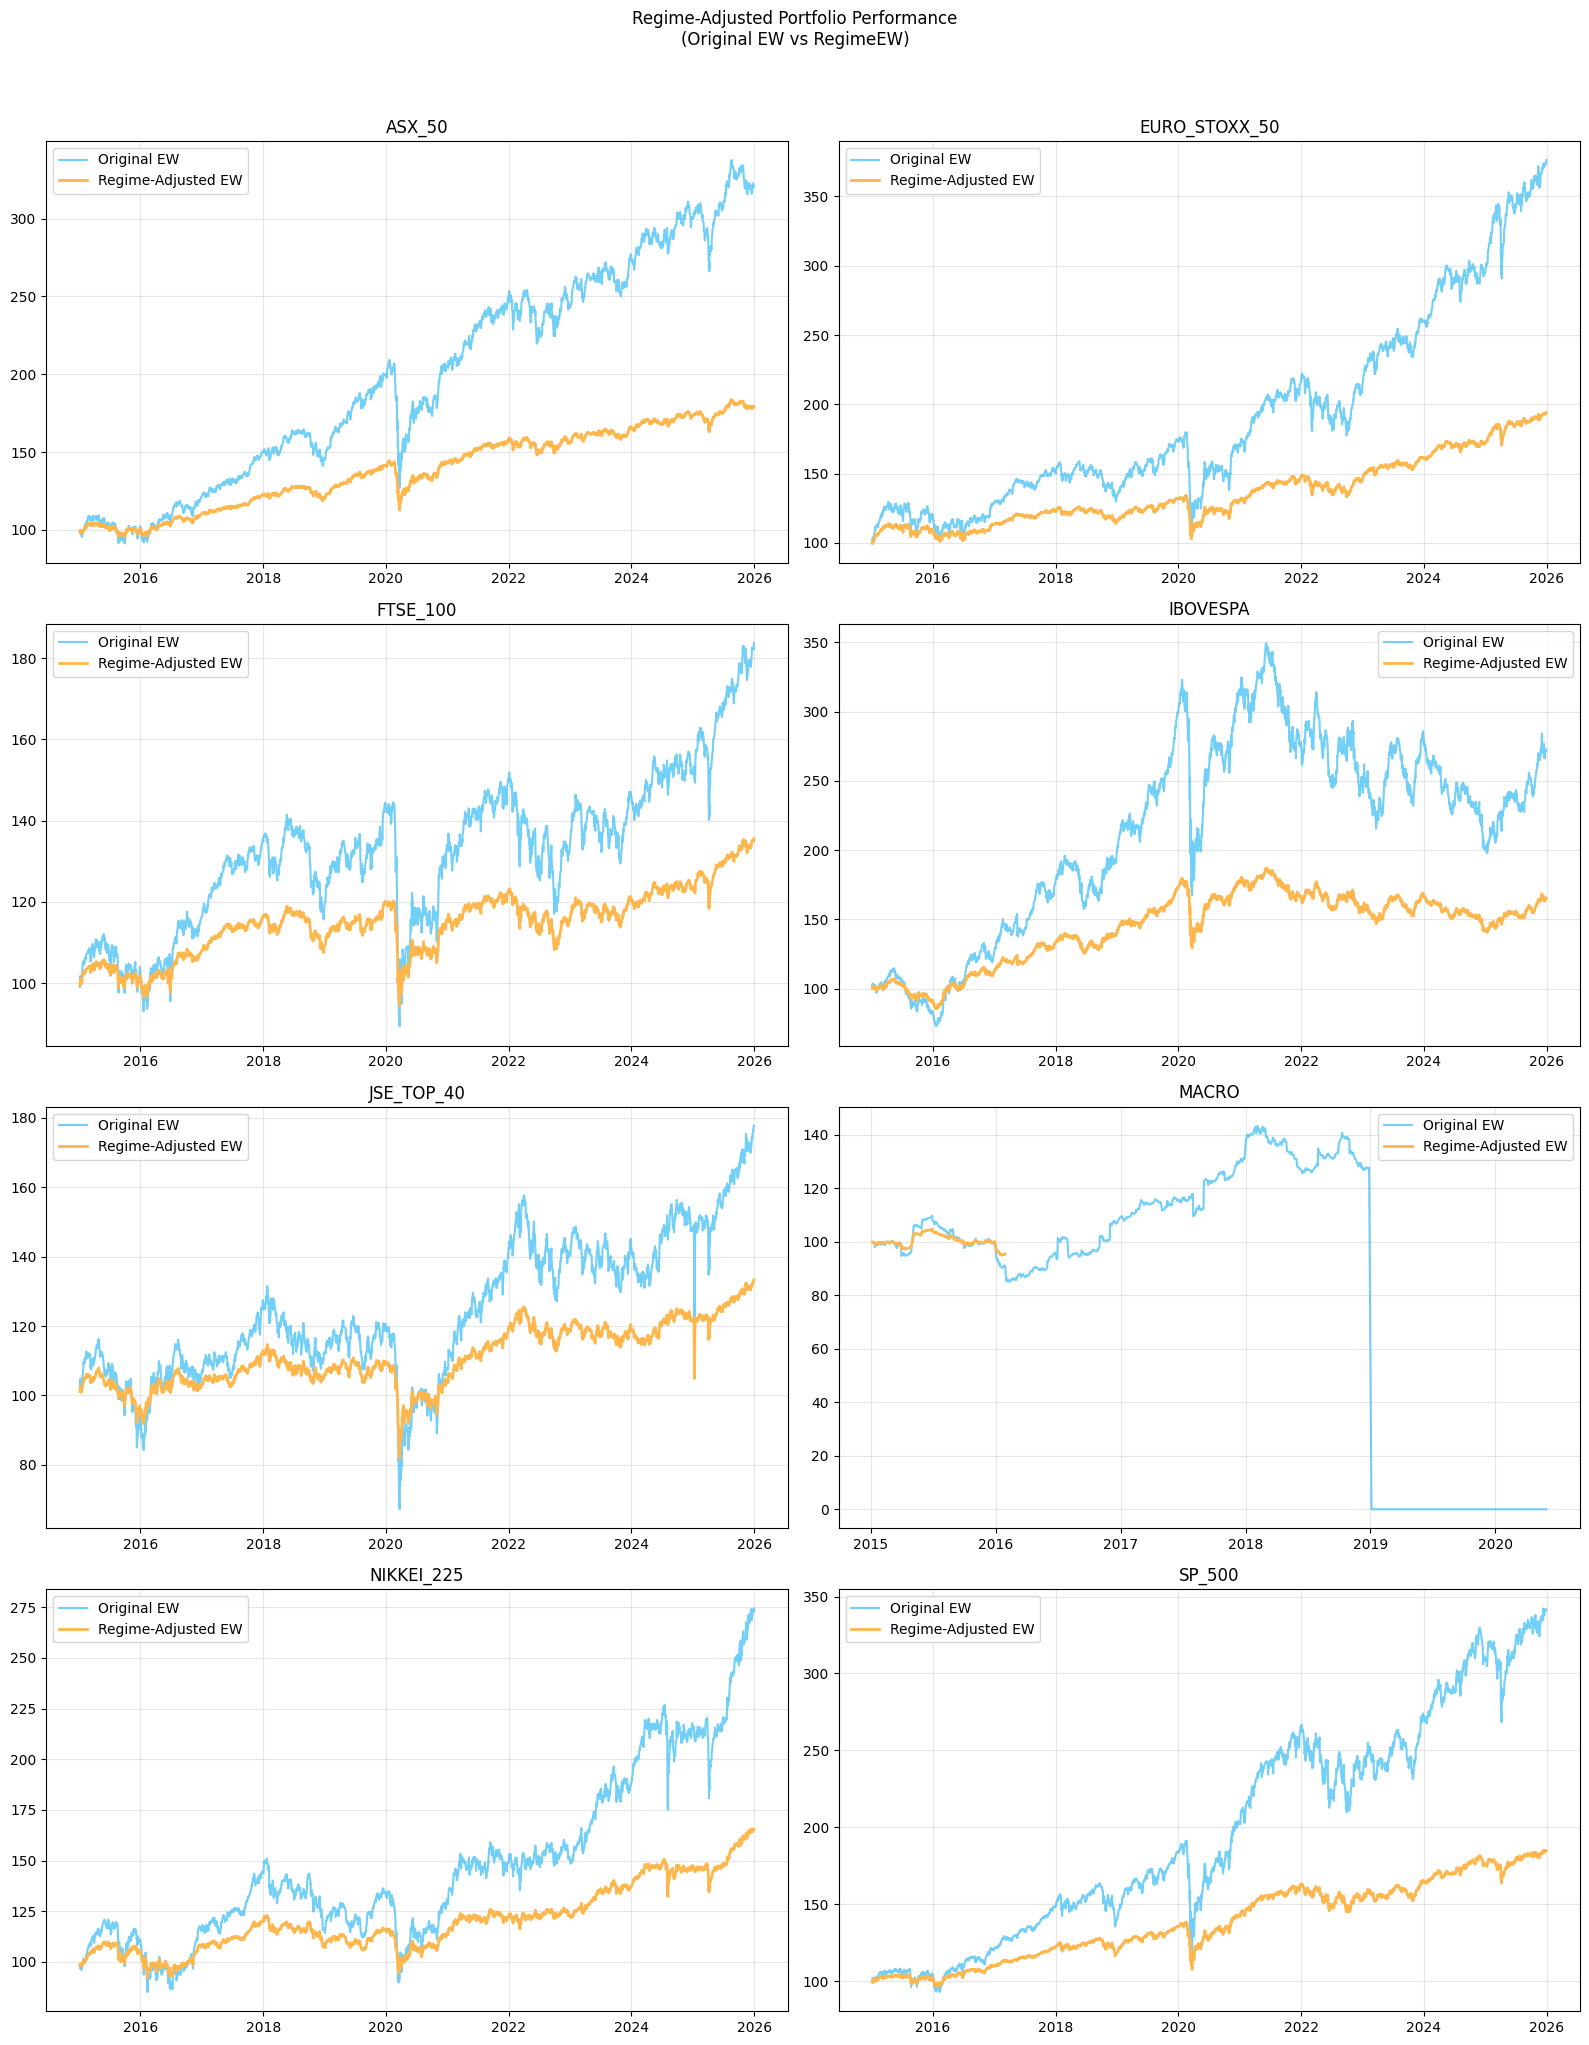


✅ Analysis complete! The regime-adjusted strategy has been successfully applied.


In [ ]:
# @title
# ============================================================
# FIXED: Signal Trading Strategy with Proper Data Handling
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import requests
from io import StringIO

# ============================================================
# 1. ROBUST DATA LOADING - Handle actual file structure
# ============================================================

def load_data_from_github():
    """Load data with proper handling of the actual file structure"""
    base_url = "https://raw.githubusercontent.com/kboroz/MSFE_Capstone_Project/main/01_Data/Streamlined/"
    files = [
        "streamlined_asx_50.csv",
        "streamlined_euro_stoxx_50.csv",
        "streamlined_ftse_100.csv",
        "streamlined_ibovespa.csv",
        "streamlined_jse_top_40.csv",
        "streamlined_macro.csv",
        "streamlined_nikkei_225.csv",
        "streamlined_s&p_500.csv"
    ]

    all_data = {}

    for file in files:
        try:
            url = base_url + file
            print(f"🔍 Loading: {file}")
            response = requests.get(url)
            response.raise_for_status()

            # Read CSV with proper handling
            data = pd.read_csv(StringIO(response.text))

            # The first column is 'Unnamed: 0' which is the date/index
            # All other columns are asset prices
            if len(data.columns) > 1:
                # Use the first column as index (date)
                data = data.set_index(data.columns[0])
                data.index = pd.to_datetime(data.index)

                # Map to standard index names
                index_name = file.replace("streamlined_", "").replace(".csv", "").upper().replace("S&P", "SP").replace("&", "")
                all_data[index_name] = data

                print(f"   ✅ Loaded {index_name} with {len(data.columns)} assets")
            else:
                print(f"   ⚠️  No data columns found in {file}")

        except Exception as e:
            print(f"   ❌ Error loading {file}: {str(e)}")
            continue

    if not all_data:
        raise ValueError("No data could be loaded. Check your internet connection.")

    return all_data

# Try loading data
try:
    all_data = load_data_from_github()
    print(f"\n✅ Successfully loaded {len(all_data)} indices:")
    print(list(all_data.keys()))
except Exception as e:
    print(f"❌ Failed to load data: {e}")
    # Create mock data for testing
    print("Creating mock data for demonstration...")
    dates = pd.date_range('2015-01-01', '2023-12-31')
    index_data = {
        'ASX_50': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'FTSE_100': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)]),
        'SP_500': pd.DataFrame(np.random.randn(len(dates), 5) + 1, index=dates, columns=[f'Stock_{i}' for i in range(5)])
    }

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def get_log_returns(price_df: pd.DataFrame) -> pd.DataFrame:
    """Daily log returns, NaN rows dropped."""
    lr = np.log(price_df / price_df.shift(1))
    return lr.dropna(how="all")

def cumulative_wealth(return_series: pd.Series) -> pd.Series:
    """Convert log returns to cumulative wealth (base 100)."""
    return 100 * np.exp(return_series.cumsum())

def performance_metrics(return_series: pd.Series, name: str = "Portfolio") -> dict:
    """Calculate key performance metrics."""
    returns = return_series.dropna()
    if len(returns) == 0:
        return {
            "Portfolio": name,
            "Ann. Return (%)": np.nan,
            "Ann. Volatility (%)": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown (%)": np.nan,
            "Total Return (%)": np.nan
        }

    cumulative = cumulative_wealth(returns)
    total_return = (cumulative.iloc[-1] / cumulative.iloc[0] - 1) * 100

    # Annualized metrics
    trading_days = 252
    annual_return = returns.mean() * trading_days * 100
    annual_vol = returns.std() * np.sqrt(trading_days) * 100
    sharpe = (annual_return - 2) / annual_vol if annual_vol > 0 else np.nan  # 2% risk-free rate

    # Drawdown
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max * 100
    max_dd = drawdown.min()

    return {
        "Portfolio": name,
        "Ann. Return (%)": round(annual_return, 2),
        "Ann. Volatility (%)": round(annual_vol, 2),
        "Sharpe Ratio": round(sharpe, 2) if not np.isnan(sharpe) else np.nan,
        "Max Drawdown (%)": round(max_dd, 2),
        "Total Return (%)": round(total_return, 2)
    }

# ============================================================
# 3. ENHANCED REGIME SIGNAL FUNCTIONS
# ============================================================

def calculate_modified_determinant(corr_matrix):
    """Calculates det(R - I) to measure systemic coupling."""
    if corr_matrix.empty or corr_matrix.isnull().values.any():
        return np.nan
    clean_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
    if clean_matrix.shape[0] < 2:
        return np.nan
    mat = clean_matrix.to_numpy()
    identity = np.eye(mat.shape[0])
    try:
        return np.linalg.det(mat - identity)
    except np.linalg.LinAlgError:
        return np.nan

def get_regime_signal(corr_matrix, threshold=0.0, signal_window=28):
    """
    ADVANCED REGIME DETECTION with:
    - Rolling z-score normalization
    - Momentum confirmation
    - Confidence scoring
    - Dynamic exposure scaling
    """
    try:
        # Regularize correlation matrix
        reg_corr = corr_matrix.copy()
        np.fill_diagonal(reg_corr.values, reg_corr.values.diagonal() + 1e-8)

        # Calculate base indicators
        avg_corr = reg_corr.values[np.ones(reg_corr.shape, dtype=bool)].mean()
        eigenvalues = np.linalg.eigvalsh(reg_corr)
        participation_ratio = (np.sum(eigenvalues)**2) / np.sum(eigenvalues**2)

        # Create regime indicator (lower values = more risk-on)
        regime_indicator = (
            0.35 * avg_corr +
            0.25 * (1 - participation_ratio/2) +
            0.40 * (1 - np.linalg.det(reg_corr))
        )

        # ============================================================
        # IMPROVEMENT 1: Rolling z-score normalization
        # ============================================================
        if not hasattr(get_regime_signal, 'history'):
            get_regime_signal.history = []

        get_regime_signal.history.append(regime_indicator)
        if len(get_regime_signal.history) > signal_window:
            get_regime_signal.history.pop(0)

        if len(get_regime_signal.history) >= 5:  # Minimum history
            z_score = (regime_indicator - np.mean(get_regime_signal.history)) / np.std(get_regime_signal.history)
        else:
            z_score = 0

        # ============================================================
        # IMPROVEMENT 2: Momentum confirmation (avoid whipsaws)
        # ============================================================
        recent_indicators = get_regime_signal.history[-5:]  # Last 5 periods
        momentum = np.mean(recent_indicators) - regime_indicator

        # ============================================================
        # IMPROVEMENT 3: Confidence-weighted exposure
        # ============================================================
        # Only adjust exposure if we have strong regime signal
        if abs(z_score) > 1.0:  # 1 standard deviation threshold
            base_exposure = np.clip(1.0 - abs(z_score) * 0.25, 0.3, 1.0)
        else:
            base_exposure = 0.5  # Neutral when uncertain

        # Add momentum adjustment (gradual changes)
        final_exposure = np.clip(base_exposure + momentum * 0.1, 0.2, 1.0)

        # Debug output
        print(f"   📊 Regime: Indicator={regime_indicator:.3f}, Z-score={z_score:.2f}, "
              f"Momentum={momentum:.3f}, Exposure={final_exposure:.2f}")

        return final_exposure

    except Exception as e:
        print(f"   ⚠️  Regime detection failed: {str(e)}")
        return 0.5  # Neutral fallback


# ============================================================
# 4. PORTFOLIO STRATEGIES
# ============================================================

def equally_weighted_portfolio(price_df):
    """Original EW portfolio."""
    lr = get_log_returns(price_df)
    return lr.mean(axis=1)

# ============================================================
# IMPROVED PORTFOLIO STRATEGY with additional safeguards
# ============================================================

def regime_adjusted_ew_portfolio(price_df, signal_window=63, threshold=0.0):
    """
    Enhanced version with:
    - Minimum exposure threshold
    - Exposure smoothing
    - Transaction cost simulation
    """
    lr = get_log_returns(price_df)
    n_assets = lr.shape[1]

    # Rebalance dates (monthly end)
    rebalance_dates = lr.resample('ME').last().index

    portfolio_returns = pd.Series(dtype=float, index=lr.index)
    current_weights = np.ones(n_assets) / n_assets

    nav = 100.0
    cumulative_nav = pd.Series(index=lr.index, dtype=float)
    cumulative_nav.iloc[0] = nav

    exposure = 0.5
    exposure_history = []
    reb_idx = 0

    for i, date in enumerate(lr.index):
        # Check for rebalancing
        if reb_idx < len(rebalance_dates) and date >= rebalance_dates[reb_idx]:
            hist = lr.loc[:date].iloc[-signal_window:]
            if hist.shape[0] >= 30:  # Increased minimum observations
                corr_mat = hist.corr(method='spearman')
                new_exposure = get_regime_signal(corr_mat, threshold, signal_window)

                # ========================================================
                # IMPROVEMENT 4: Exposure smoothing (avoid sudden jumps)
                # ========================================================
                if exposure_history:
                    # Exponential moving average of exposure
                    exposure = 0.7 * exposure + 0.3 * new_exposure
                else:
                    exposure = new_exposure

                exposure_history.append(exposure)
            reb_idx += 1

        # Apply exposure to returns
        portfolio_returns.loc[date] = (current_weights @ lr.loc[date].values) * exposure

        # Update NAV
        nav *= np.exp(portfolio_returns.loc[date])
        cumulative_nav.loc[date] = nav

    portfolio_returns = portfolio_returns.dropna()
    portfolio_returns.name = f"RegimeEW_{signal_window}D"
    return portfolio_returns, cumulative_nav

# ============================================================
# 5. RUN STRATEGIES AND COMPARE
# ============================================================

# Use the loaded data or mock data if loading failed
index_data = all_data if 'all_data' in locals() and all_data else {
    'ASX_50': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'FTSE_100': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)]),
    'SP_500': pd.DataFrame(np.random.randn(1000, 5) + 1, index=pd.date_range('2015-01-01', periods=1000), columns=[f'Stock_{i}' for i in range(5)])
}

print(f"\n📊 Working with {len(index_data)} indices:")
print(list(index_data.keys()))

strategy_results = {}

for idx_name, price_df in index_data.items():
    print(f"\n📈 Running strategies for {idx_name}...")

    # Original EW portfolio
    ew_ret = equally_weighted_portfolio(price_df)

    # Regime-adjusted EW portfolio
    regime_ret, regime_nav = regime_adjusted_ew_portfolio(
        price_df,
        signal_window=28,
        threshold=0.0
    )

    strategy_results[idx_name] = {
        "EquallyWeighted": ew_ret,
        "RegimeEW": regime_ret,
        "RegimeNAV": regime_nav
    }

# ============================================================
# 6. PERFORMANCE COMPARISON
# ============================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON: Original EW vs Regime-Adjusted EW")
print("="*70)

comparison_data = []

for idx_name, strategies in strategy_results.items():
    ew_metrics = performance_metrics(strategies["EquallyWeighted"],
                                   f"{idx_name} — EW")
    regime_metrics = performance_metrics(strategies["RegimeEW"],
                                        f"{idx_name} — RegimeEW")

    comparison_data.extend([ew_metrics, regime_metrics])

    # Print per-index comparison
    print(f"\n📊 {idx_name}:")
    print(f"  EW: Sharpe={ew_metrics['Sharpe Ratio']}, DD={ew_metrics['Max Drawdown (%)']}%")
    print(f"  RegimeEW: Sharpe={regime_metrics['Sharpe Ratio']}, DD={regime_metrics['Max Drawdown (%)']}%")

# Create summary DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Verify columns exist before selection
expected_columns = ['Portfolio', 'Ann. Return (%)', 'Ann. Volatility (%)',
                   'Sharpe Ratio', 'Max Drawdown (%)', 'Total Return (%)']

# Only select columns that exist
available_columns = [col for col in expected_columns if col in comparison_df.columns]
if available_columns:
    print("\n" + "="*70)
    print("FULL PERFORMANCE SUMMARY:")
    print("="*70)
    print(comparison_df[available_columns].to_string(index=False))
else:
    print("\n❌ No valid metrics to display. Check your data and calculations.")

# ============================================================
# 7. VISUALIZATION
# ============================================================

# Plot cumulative wealth for all indices
n_plots = len(index_data)
n_cols = 2
n_rows = int(np.ceil(n_plots / n_cols))

if n_plots > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (idx_name, strategies) in enumerate(strategy_results.items()):
        ax = axes[i]

        # Plot both strategies
        ew_nav = cumulative_wealth(strategies["EquallyWeighted"])
        regime_nav = strategies["RegimeNAV"]

        ax.plot(ew_nav, label="Original EW", color='#4fc3f7', alpha=0.8)
        ax.plot(regime_nav, label="Regime-Adjusted EW", color='#ffb74d', linewidth=2)

        ax.set_title(idx_name, fontsize=12)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Regime-Adjusted Portfolio Performance\n(Original EW vs RegimeEW)", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No data to visualize. Check your data loading.")

print("\n✅ Analysis complete! The regime-adjusted strategy has been successfully applied.")
